# PHASE 3 — Dataset Loading
## Multimodal Maritime Object Detection Using SAR and Optical Satellite Imagery
---
**Team 22UG0005 | Panel No. 5 | Guide: Mr. Nagesh Koundinya Subbanna**

---
## WHY DO WE NEED PHASE 3?

After Phase 0, 1, 2 we have:
```
193,460 preprocessed optical images  (320x320)
193,460 preprocessed SAR images      (320x320)
193,460 YOLO label .txt files        (bounding boxes)
```

But the deep learning model (PyTorch) cannot read PNG files directly.
It needs data delivered as TENSORS in organised BATCHES.
That is exactly what Phase 3 builds — a PyTorch Dataset and DataLoader.

---
## WHAT IS A DATASET AND DATALOADER?

**Dataset** = A Python class that knows:
  - How many samples exist
  - How to load one sample: (SAR tensor, optical tensor, label tensor)

**DataLoader** = A wrapper around Dataset that:
  - Loads samples in parallel (multiple workers)
  - Groups them into batches (e.g. 4 images at once)
  - Shuffles training data each epoch
  - Pins memory for faster GPU/CPU transfer

---
## WHY STRATIFIED SUBSAMPLING?

We have 193,460 images but only 10,000 are used for training.
WHY? Because we are on a CPU-only laptop. Training on 193K images
would take weeks on CPU.

BUT — we cannot just take 10,000 random images. The dataset is
VERY imbalanced:
```
42,556  images have ships   (22%)
150,904 images have NO ships (78%)
```
If we randomly sample 10,000, we might get 9,500 background images
and only 500 ship images. The model would learn to ALWAYS predict
'no ship' and still get 95% accuracy — which is useless.

SOLUTION = STRATIFIED sampling:
```
5,000 ship images      (positive samples)
5,000 background images (negative samples)
= 10,000 total, perfectly balanced 50/50
```
This FORCES the model to learn what ships look like.

---
## WHY 90% TRAIN / 10% VALIDATION SPLIT?

From 10,000 stratified samples:
```
9,000 images -> training   (model learns from these)
1,000 images -> validation (model is tested on these each epoch)
```
Validation images are NEVER used for learning.
They tell us honestly: is the model actually getting better,
or is it just memorising the training data?

---
## WHAT DOES THE DATALOADER SERVE PER BATCH?

Each batch contains:
```
sar_tensor    : shape [4, 1, 320, 320]  (batch=4, channels=1, H=320, W=320)
optical_tensor: shape [4, 3, 320, 320]  (batch=4, channels=3 RGB, H=320, W=320)
labels        : list of 4 tensors, each shape [N, 5] (N ships, 5 = class+xywh)
image_ids     : list of 4 filenames (for debugging)
```

---
## Input (from Phase 1 and Phase 2):
```
dataset/
    preprocessed_train_OPTICAL/  193,460 images
    preprocessed_train_SAR/      193,460 images
    labels/                      193,460 .txt files
```

## Output after Phase 3:
```
train_loader  -> 9,000 images, batch size 4, augmentation ON
val_loader    -> 1,000 images, batch size 4, augmentation OFF
dataset_samples/ -> visualisation of sample batches for panel
```

## Cell 1 — Install Libraries

In [1]:
import subprocess, sys
required = ['torch', 'torchvision', 'opencv-python', 'numpy',
            'pandas', 'matplotlib', 'tqdm']
for pkg in required:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All libraries installed successfully.')

All libraries installed successfully.


## Cell 2 — Imports

In [2]:
import os, sys, io, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# Fix Windows Unicode printing
if hasattr(sys.stdout, "buffer"):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')
# Set all random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('All imports successful.')
print(f'  NumPy  : {np.__version__}')
print(f'  Pandas : {pd.__version__}')
print(f'  PyTorch: {torch.__version__}')
print(f'  OpenCV : {cv2.__version__}')
print(f'  Run at : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print()

# Check if CUDA is available (expected: NO on CPU-only laptop)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  Device : {device}')
if device.type == 'cpu':
    print('  Running on CPU — this is expected on your laptop.')
    print('  Training will use all CPU cores via torch.set_num_threads(8)')
    torch.set_num_threads(8)   # use all 8 cores of Intel i5-12450H
else:
    print('  CUDA GPU detected — full speed training available!')

All imports successful.
  NumPy  : 2.4.3
  Pandas : 3.0.1
  PyTorch: 2.11.0+cpu
  OpenCV : 4.13.0
  Run at : 2026-04-24 11:15:14

  Device : cpu
  Running on CPU — this is expected on your laptop.
  Training will use all CPU cores via torch.set_num_threads(8)


## Cell 3 — Configuration

In [3]:
# =====================================================================
#   EDIT ONLY THIS CELL
# =====================================================================

ROOT        = r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection'
DATASET_DIR = os.path.join( r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset')

# -- INPUTS from Phase 1 and Phase 2 ----------------------------------
OPT_DIR    = os.path.join(DATASET_DIR, 'preprocessed_train_OPTICAL')
SAR_DIR    = os.path.join(DATASET_DIR, 'preprocessed_train_SAR')
LABEL_DIR  = os.path.join(DATASET_DIR, 'labels')

# -- OUTPUTS ----------------------------------------------------------
OUT_SAMPLES   = os.path.join(DATASET_DIR, 'dataset_samples')
SUMMARY_FILE  = os.path.join(DATASET_DIR, 'phase3_summary.txt')

# -- STRATIFIED SUBSET SETTINGS ---------------------------------------
# From methodology: 5,000 ship + 5,000 background = 10,000 total
# This is a hardware constraint — CPU-only training on 16GB RAM
NUM_SHIP_SAMPLES = 5000    # positive samples (images with ships)
NUM_BG_SAMPLES   = 5000    # negative samples (background images)
TOTAL_SAMPLES    = NUM_SHIP_SAMPLES + NUM_BG_SAMPLES  # 10,000

# -- TRAIN / VALIDATION SPLIT -----------------------------------------
# 90% train, 10% validation (from methodology)
VAL_FRACTION  = 0.10   # 10% of 10,000 = 1,000 val images

# -- DATALOADER SETTINGS ----------------------------------------------
BATCH_SIZE    = 4       # hardware constraint: 16GB RAM, CPU only
NUM_WORKERS   = 0       # Windows multiprocessing limit (from methodology)
PIN_MEMORY    = False   # True only for GPU; False for CPU

# -- IMAGE DIMENSIONS (must match Phase 1 output) ---------------------
IMG_H = 320
IMG_W = 320

os.makedirs(OUT_SAMPLES, exist_ok=True)

print('Configuration loaded.')
print(f'  ROOT                : {ROOT}')
print(f'  Optical images      : {OPT_DIR}')
print(f'  SAR images          : {SAR_DIR}')
print(f'  Label files         : {LABEL_DIR}')
print()
print(f'  Stratified subset   : {NUM_SHIP_SAMPLES:,} ship + {NUM_BG_SAMPLES:,} background = {TOTAL_SAMPLES:,} total')
print(f'  Train/val split     : {int((1-VAL_FRACTION)*100)}% / {int(VAL_FRACTION*100)}%')
print(f'    -> Train samples  : {int(TOTAL_SAMPLES * (1-VAL_FRACTION)):,}')
print(f'    -> Val samples    : {int(TOTAL_SAMPLES * VAL_FRACTION):,}')
print(f'  Batch size          : {BATCH_SIZE}')
print(f'  Num workers         : {NUM_WORKERS}  (Windows limit)')
print(f'  Image size          : {IMG_H}x{IMG_W}')
print(f'  Device              : {device}')

Configuration loaded.
  ROOT                : C:\Users\VaishnaviM\Downloads\airbus-ship-detection
  Optical images      : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\preprocessed_train_OPTICAL
  SAR images          : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\preprocessed_train_SAR
  Label files         : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\labels

  Stratified subset   : 5,000 ship + 5,000 background = 10,000 total
  Train/val split     : 90% / 10%
    -> Train samples  : 9,000
    -> Val samples    : 1,000
  Batch size          : 4
  Num workers         : 0  (Windows limit)
  Image size          : 320x320
  Device              : cpu


## Cell 4 — Verify Phase 1 and Phase 2 Outputs Exist

In [4]:
print('Verifying Phase 1 and Phase 2 outputs...')

checks = {
    'preprocessed_train_OPTICAL' : OPT_DIR,
    'preprocessed_train_SAR'     : SAR_DIR,
    'labels/'                    : LABEL_DIR,
}

all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status:^7}]  {name:35} -> {path}')
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        'Missing input folders. Run Phase 1 and Phase 2 first.'
    )

print()

opt_files   = sorted([f for f in os.listdir(OPT_DIR)   if f.endswith('_opt.png')])
sar_files   = set(os.listdir(SAR_DIR))
label_files = set(os.listdir(LABEL_DIR))

print(f'  Optical images found  : {len(opt_files):,}')
print(f'  SAR images found      : {len(sar_files):,}')
print(f'  Label files found     : {len(label_files):,}')
print()

# Count ship vs background based on label file size
ship_ids, bg_ids = [], []
for opt_fname in opt_files:
    seq_id    = opt_fname.replace('_opt.png', '')
    sar_fname = f'{seq_id}_sar.png'
    lbl_fname = f'{seq_id}.txt'

    if sar_fname not in sar_files or lbl_fname not in label_files:
        continue

    lbl_path = os.path.join(LABEL_DIR, lbl_fname)
    if os.path.getsize(lbl_path) > 0:
        ship_ids.append(seq_id)
    else:
        bg_ids.append(seq_id)

print(f'  Complete pairs found  : {len(ship_ids)+len(bg_ids):,}')
print(f'  Ship images (non-empty label) : {len(ship_ids):,}')
print(f'  Background images (empty label): {len(bg_ids):,}')
print()
print('All inputs verified. Ready for stratified sampling.')

Verifying Phase 1 and Phase 2 outputs...
  [  OK   ]  preprocessed_train_OPTICAL          -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\preprocessed_train_OPTICAL
  [  OK   ]  preprocessed_train_SAR              -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\preprocessed_train_SAR
  [  OK   ]  labels/                             -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\labels

  Optical images found  : 193,460
  SAR images found      : 193,460
  Label files found     : 193,460

  Complete pairs found  : 193,460
  Ship images (non-empty label) : 42,556
  Background images (empty label): 150,904

All inputs verified. Ready for stratified sampling.


## Cell 5 — Stratified Sampling
### WHY: Prevent model collapse by balancing ship vs background images

In [5]:
# =====================================================================
#  STRATIFIED SAMPLING — WHY THIS IS CRITICAL
#
#  The full dataset has 150,904 background images and 42,556 ship images.
#  Ratio: 78% background, 22% ships.
#
#  If we randomly sample 10,000 images:
#    ~7,800 would be background, ~2,200 would have ships.
#  The model can get 78% accuracy by just predicting 'no ship' always.
#  It never learns to detect anything useful.
#
#  SOLUTION: Force exactly 50% ship, 50% background.
#  The model MUST learn what ships look like to succeed.
# =====================================================================

print('STRATIFIED SAMPLING')
print()
print(f'  Full dataset breakdown:')
print(f'    Ship images     : {len(ship_ids):,}  ({len(ship_ids)/(len(ship_ids)+len(bg_ids))*100:.1f}%)')
print(f'    Background      : {len(bg_ids):,}  ({len(bg_ids)/(len(ship_ids)+len(bg_ids))*100:.1f}%)')
print()
print(f'  Without stratification (random 10,000):')
approx_ship = int(len(ship_ids)/(len(ship_ids)+len(bg_ids)) * TOTAL_SAMPLES)
approx_bg   = TOTAL_SAMPLES - approx_ship
print(f'    ~{approx_ship:,} ship images -> model barely sees ships')
print(f'    ~{approx_bg:,} background   -> model learns to predict nothing')
print(f'    Result: model collapse (always predicts no ship = 78% accuracy)')
print()
print(f'  WITH stratification (what we do):')
print(f'    {NUM_SHIP_SAMPLES:,} ship images  (50%)')
print(f'    {NUM_BG_SAMPLES:,} background   (50%)')
print(f'    Result: balanced training, model must learn ship detection')
print()

# Perform stratified sampling with fixed seed for reproducibility
random.seed(SEED)

# Check we have enough samples
if len(ship_ids) < NUM_SHIP_SAMPLES:
    print(f'  WARNING: Only {len(ship_ids):,} ship images available, using all of them.')
    sampled_ship = ship_ids[:]
else:
    sampled_ship = random.sample(ship_ids, NUM_SHIP_SAMPLES)

if len(bg_ids) < NUM_BG_SAMPLES:
    print(f'  WARNING: Only {len(bg_ids):,} background images available, using all of them.')
    sampled_bg = bg_ids[:]
else:
    sampled_bg = random.sample(bg_ids, NUM_BG_SAMPLES)

# Combine and shuffle
all_sampled_ids = sampled_ship + sampled_bg
random.shuffle(all_sampled_ids)

print(f'  Stratified subset built:')
print(f'    Ship samples    : {len(sampled_ship):,}')
print(f'    BG samples      : {len(sampled_bg):,}')
print(f'    Total           : {len(all_sampled_ids):,}')
print(f'    Shuffled        : YES (seed={SEED})')
print()
print(f'  First 5 sampled IDs: {all_sampled_ids[:5]}')
print()
print('Stratified sampling complete.')

STRATIFIED SAMPLING

  Full dataset breakdown:
    Ship images     : 42,556  (22.0%)
    Background      : 150,904  (78.0%)

  Without stratification (random 10,000):
    ~2,199 ship images -> model barely sees ships
    ~7,801 background   -> model learns to predict nothing
    Result: model collapse (always predicts no ship = 78% accuracy)

  WITH stratification (what we do):
    5,000 ship images  (50%)
    5,000 background   (50%)
    Result: balanced training, model must learn ship detection

  Stratified subset built:
    Ship samples    : 5,000
    BG samples      : 5,000
    Total           : 10,000
    Shuffled        : YES (seed=42)

  First 5 sampled IDs: ['12784', '186145', '83373', '50087', '162746']

Stratified sampling complete.


## Cell 6 — Define the PyTorch Dataset Class

In [6]:
# =====================================================================
#  MARITIMEMULTIMODALDATASET — PyTorch Dataset
#
#  A PyTorch Dataset must implement 3 methods:
#    __init__  : store config, file lists
#    __len__   : return total number of samples
#    __getitem__: load and return ONE sample given an index
#
#  Each sample returned is a tuple:
#    sar_tensor    : float32 [1, 320, 320]  (1 channel, normalised)
#    optical_tensor: float32 [3, 320, 320]  (3 channels RGB, normalised)
#    labels        : float32 [N, 5]         (N ships x [class,xc,yc,w,h])
#    image_id      : str                    (filename for debugging)
# =====================================================================

class MaritimeMultimodalDataset(Dataset):
    """
    PyTorch Dataset for multimodal maritime ship detection.

    Loads paired SAR + optical images and their YOLO bounding box labels.
    Each call to __getitem__ returns one (SAR, optical, labels) triplet.

    The dataset was preprocessed in Phase 1 (images saved to disk)
    and annotated in Phase 2 (labels saved to .txt files).
    This class simply READS those files and converts them to tensors.
    """

    def __init__(self, seq_ids, opt_dir, sar_dir, label_dir,
                 img_h=320, img_w=320):
        """
        Args:
            seq_ids   : list of sequential IDs, e.g. ['00001', '00042', ...]
            opt_dir   : path to preprocessed_train_OPTICAL/
            sar_dir   : path to preprocessed_train_SAR/
            label_dir : path to labels/
            img_h     : image height (320)
            img_w     : image width  (320)
        """
        self.seq_ids   = seq_ids
        self.opt_dir   = opt_dir
        self.sar_dir   = sar_dir
        self.label_dir = label_dir
        self.img_h     = img_h
        self.img_w     = img_w

    def __len__(self):
        """
        Returns: total number of samples in this dataset split.
        PyTorch calls this to know when one epoch ends.
        """
        return len(self.seq_ids)

    def __getitem__(self, idx):
        """
        Loads and returns ONE sample: (sar_tensor, opt_tensor, labels, image_id)

        Steps:
          1. Get the sequential ID for this index (e.g. '00042')
          2. Read SAR image (grayscale) -> float32 tensor [1, H, W]
          3. Read optical image (RGB)   -> float32 tensor [3, H, W]
          4. Read YOLO label .txt file  -> float32 tensor [N, 5]
          5. Return the triplet

        NOTE: Images were already preprocessed and normalised in Phase 1.
        We simply divide by 255 to get [0,1] float32 tensors.
        NO augmentation is applied here — Phase 1 already did that.
        """
        seq_id = self.seq_ids[idx]

        # ── Step 1: Build file paths ──────────────────────────────────
        opt_path = os.path.join(self.opt_dir,   f'{seq_id}_opt.png')
        sar_path = os.path.join(self.sar_dir,   f'{seq_id}_sar.png')
        lbl_path = os.path.join(self.label_dir, f'{seq_id}.txt')

        # ── Step 2: Load SAR image ────────────────────────────────────
        # SAR is single-channel (grayscale)
        sar_img = cv2.imread(sar_path, cv2.IMREAD_GRAYSCALE)
        if sar_img is None:
            # Fallback: return zeros if file is missing
            sar_img = np.zeros((self.img_h, self.img_w), dtype=np.uint8)

        # Convert to float32 [0, 1]
        sar_arr = sar_img.astype(np.float32) / 255.0

        # Add channel dimension: (H, W) -> (1, H, W)
        sar_tensor = torch.from_numpy(sar_arr).unsqueeze(0)  # [1, H, W]

        # ── Step 3: Load optical image ────────────────────────────────
        # Optical is 3-channel (BGR from OpenCV -> convert to RGB)
        opt_img = cv2.imread(opt_path, cv2.IMREAD_COLOR)
        if opt_img is None:
            opt_img = np.zeros((self.img_h, self.img_w, 3), dtype=np.uint8)

        # Convert BGR to RGB, then to float32 [0, 1]
        opt_rgb = cv2.cvtColor(opt_img, cv2.COLOR_BGR2RGB)
        opt_arr = opt_rgb.astype(np.float32) / 255.0

        # Convert (H, W, 3) -> (3, H, W) for PyTorch convention
        opt_tensor = torch.from_numpy(opt_arr).permute(2, 0, 1)  # [3, H, W]

        # ── Step 4: Load YOLO labels ──────────────────────────────────
        labels = []
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    if len(parts) == 5:
                        # [class, x_center, y_center, width, height]
                        labels.append([float(p) for p in parts])

        # Convert to tensor
        if labels:
            label_tensor = torch.tensor(labels, dtype=torch.float32)  # [N, 5]
        else:
            # Empty label: zero tensor [0, 5] for background images
            label_tensor = torch.zeros((0, 5), dtype=torch.float32)

        return sar_tensor, opt_tensor, label_tensor, seq_id


# ── Custom collate function ───────────────────────────────────────────
# PyTorch's default collate_fn cannot stack variable-size label tensors
# (different images have different numbers of ships).
# This custom function handles that correctly.

def collate_fn(batch):
    """
    Custom batch collation for variable-size labels.

    Why needed:
    - Image 1 might have 3 ships  -> labels shape [3, 5]
    - Image 2 might have 0 ships  -> labels shape [0, 5]
    - Image 3 might have 7 ships  -> labels shape [7, 5]
    - torch.stack() requires SAME size -> would crash

    Solution: stack SAR and optical (always same size),
              keep labels as a LIST (variable size is fine).
    """
    sar_tensors  = torch.stack([item[0] for item in batch])   # [B, 1, H, W]
    opt_tensors  = torch.stack([item[1] for item in batch])   # [B, 3, H, W]
    label_list   = [item[2] for item in batch]                # list of [N, 5]
    image_ids    = [item[3] for item in batch]                # list of str
    return sar_tensors, opt_tensors, label_list, image_ids


print('MaritimeMultimodalDataset class defined.')
print()
print('  __len__()      : returns total number of samples')
print('  __getitem__(i) : loads ONE sample at index i')
print('    -> SAR tensor  : float32 [1, 320, 320]  (single channel)')
print('    -> OPT tensor  : float32 [3, 320, 320]  (RGB channels)')
print('    -> labels      : float32 [N, 5]         (N ships per image)')
print('    -> image_id    : str                    (for debugging)')
print()
print('collate_fn() defined — handles variable-size label tensors.')

MaritimeMultimodalDataset class defined.

  __len__()      : returns total number of samples
  __getitem__(i) : loads ONE sample at index i
    -> SAR tensor  : float32 [1, 320, 320]  (single channel)
    -> OPT tensor  : float32 [3, 320, 320]  (RGB channels)
    -> labels      : float32 [N, 5]         (N ships per image)
    -> image_id    : str                    (for debugging)

collate_fn() defined — handles variable-size label tensors.


## Cell 7 — Create Dataset and Train/Val Split

In [7]:
print('CREATING DATASET AND TRAIN/VAL SPLIT')
print()

# Create the full stratified dataset
full_dataset = MaritimeMultimodalDataset(
    seq_ids   = all_sampled_ids,
    opt_dir   = OPT_DIR,
    sar_dir   = SAR_DIR,
    label_dir = LABEL_DIR,
    img_h     = IMG_H,
    img_w     = IMG_W
)

print(f'  Full stratified dataset size : {len(full_dataset):,} samples')
print()

# ── Train / Validation Split ─────────────────────────────────────────
# 90% training, 10% validation — from methodology
# random_split uses a generator for reproducibility
val_size   = int(len(full_dataset) * VAL_FRACTION)      # 1,000
train_size = len(full_dataset) - val_size               # 9,000

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=generator
)

print(f'  Train/Val split (seed={SEED}):')
print(f'    Train samples : {len(train_dataset):,}  ({len(train_dataset)/len(full_dataset)*100:.0f}%)')
print(f'    Val   samples : {len(val_dataset):,}  ({len(val_dataset)/len(full_dataset)*100:.0f}%)')
print()
print(f'  Why random_split and not manual split?')
print(f'    -> It ensures no overlap between train and val')
print(f'    -> The same seed always gives the same split (reproducible)')
print(f'    -> Val images are NEVER seen during training')
print()

# Calculate batches per epoch
train_batches = train_size // BATCH_SIZE
val_batches   = val_size   // BATCH_SIZE
print(f'  Batches per epoch:')
print(f'    Train : {train_batches:,} batches  ({train_size:,} images / batch size {BATCH_SIZE})')
print(f'    Val   : {val_batches:,} batches  ({val_size:,} images / batch size {BATCH_SIZE})')
print()
print('Dataset split complete.')

CREATING DATASET AND TRAIN/VAL SPLIT

  Full stratified dataset size : 10,000 samples

  Train/Val split (seed=42):
    Train samples : 9,000  (90%)
    Val   samples : 1,000  (10%)

  Why random_split and not manual split?
    -> It ensures no overlap between train and val
    -> The same seed always gives the same split (reproducible)
    -> Val images are NEVER seen during training

  Batches per epoch:
    Train : 2,250 batches  (9,000 images / batch size 4)
    Val   : 250 batches  (1,000 images / batch size 4)

Dataset split complete.


## Cell 8 — Create DataLoaders

In [8]:
# =====================================================================
#  CREATING DATALOADERS
#
#  DataLoader wraps a Dataset and handles:
#    - Batching: groups multiple samples together
#    - Shuffling: randomises order each epoch (train only)
#    - Parallel loading: num_workers processes load data simultaneously
#    - pin_memory: pins tensors in RAM for faster GPU transfer
#
#  WHY shuffle=True for train but False for val?
#    Train: shuffle prevents the model seeing the same order each epoch,
#           which would cause it to memorise sequence patterns.
#    Val:   no shuffle needed — we just want consistent evaluation.
#
#  WHY num_workers=0 on Windows?
#    Windows has a known multiprocessing issue with PyTorch.
#    More than 2 workers often causes deadlocks or crashes on Windows.
#    2 is the safe maximum from the methodology.
#
#  WHY pin_memory=False?
#    pin_memory=True speeds up CPU->GPU transfer.
#    Since we are on CPU-only, it has no benefit and wastes RAM.
# =====================================================================

print('CREATING DATALOADERS')
print()

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,           # randomise each epoch
    num_workers = NUM_WORKERS,    # parallel data loading
    pin_memory  = PIN_MEMORY,     # False for CPU
    collate_fn  = collate_fn,     # handles variable-size labels
    drop_last   = True,           # drop incomplete last batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,          # no shuffle for validation
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY,
    collate_fn  = collate_fn,
    drop_last   = False,          # keep all val images
)

print(f'  train_loader created:')
print(f'    Dataset    : {len(train_dataset):,} samples')
print(f'    Batch size : {BATCH_SIZE}')
print(f'    Batches    : {len(train_loader):,} per epoch')
print(f'    Shuffle    : True')
print(f'    Workers    : {NUM_WORKERS}')
print(f'    drop_last  : True  (drops incomplete final batch)')
print()
print(f'  val_loader created:')
print(f'    Dataset    : {len(val_dataset):,} samples')
print(f'    Batch size : {BATCH_SIZE}')
print(f'    Batches    : {len(val_loader):,} per epoch')
print(f'    Shuffle    : False')
print(f'    Workers    : {NUM_WORKERS}')
print()
print('Both DataLoaders ready.')

CREATING DATALOADERS

  train_loader created:
    Dataset    : 9,000 samples
    Batch size : 4
    Batches    : 2,250 per epoch
    Shuffle    : True
    Workers    : 0
    drop_last  : True  (drops incomplete final batch)

  val_loader created:
    Dataset    : 1,000 samples
    Batch size : 4
    Batches    : 250 per epoch
    Shuffle    : False
    Workers    : 0

Both DataLoaders ready.


## Cell 9 — Load and Verify One Batch

In [9]:
print('LOADING ONE BATCH — FULL VERIFICATION')
print()
print('Fetching first batch from train_loader...')
print()

# Load one batch
sample_batch = next(iter(train_loader))
sar_batch, opt_batch, labels_batch, ids_batch = sample_batch

print(f'  Batch loaded successfully!')
print()
print(f'  sar_batch shape    : {sar_batch.shape}')
print(f'    Meaning          : [batch={sar_batch.shape[0]}, channels={sar_batch.shape[1]}, H={sar_batch.shape[2]}, W={sar_batch.shape[3]}]')
print(f'    dtype            : {sar_batch.dtype}')
print(f'    min / max        : {sar_batch.min():.4f} / {sar_batch.max():.4f}')
print(f'    mean             : {sar_batch.mean():.4f}')
print()
print(f'  opt_batch shape    : {opt_batch.shape}')
print(f'    Meaning          : [batch={opt_batch.shape[0]}, channels={opt_batch.shape[1]} (RGB), H={opt_batch.shape[2]}, W={opt_batch.shape[3]}]')
print(f'    dtype            : {opt_batch.dtype}')
print(f'    min / max        : {opt_batch.min():.4f} / {opt_batch.max():.4f}')
print(f'    mean             : {opt_batch.mean():.4f}')
print()
print(f'  labels_batch       : list of {len(labels_batch)} tensors')
for i, lbl in enumerate(labels_batch):
    ships = lbl.shape[0]
    print(f'    Image {i+1} [{ids_batch[i]}] : {lbl.shape}  -> {ships} ship(s)')
    if ships > 0:
        print(f'      First box : class={int(lbl[0,0])}  '
              f'xc={lbl[0,1]:.4f}  yc={lbl[0,2]:.4f}  '
              f'w={lbl[0,3]:.4f}  h={lbl[0,4]:.4f}')
print()
print(f'  image_ids          : {ids_batch}')
print()

# Assertions
assert sar_batch.shape == (BATCH_SIZE, 1, IMG_H, IMG_W), \
    f'SAR shape wrong: {sar_batch.shape}'
assert opt_batch.shape == (BATCH_SIZE, 3, IMG_H, IMG_W), \
    f'OPT shape wrong: {opt_batch.shape}' 
assert sar_batch.dtype == torch.float32, 'SAR should be float32'
assert opt_batch.dtype == torch.float32, 'OPT should be float32'
assert 0.0 <= sar_batch.min() and sar_batch.max() <= 1.0, \
    'SAR values out of [0, 1]'
assert 0.0 <= opt_batch.min() and opt_batch.max() <= 1.0, \
    'OPT values out of [0, 1]'

print('ALL ASSERTIONS PASSED.')
print('  SAR shape   : CORRECT')
print('  OPT shape   : CORRECT')
print('  dtype       : CORRECT (float32)')
print('  value range : CORRECT [0.0, 1.0]')

LOADING ONE BATCH — FULL VERIFICATION

Fetching first batch from train_loader...

  Batch loaded successfully!

  sar_batch shape    : torch.Size([4, 1, 320, 320])
    Meaning          : [batch=4, channels=1, H=320, W=320]
    dtype            : torch.float32
    min / max        : 0.0118 / 0.9882
    mean             : 0.5725

  opt_batch shape    : torch.Size([4, 3, 320, 320])
    Meaning          : [batch=4, channels=3 (RGB), H=320, W=320]
    dtype            : torch.float32
    min / max        : 0.0118 / 0.9137
    mean             : 0.2726

  labels_batch       : list of 4 tensors
    Image 1 [01217] : torch.Size([0, 5])  -> 0 ship(s)
    Image 2 [103027] : torch.Size([0, 5])  -> 0 ship(s)
    Image 3 [125221] : torch.Size([1, 5])  -> 1 ship(s)
      First box : class=0  xc=0.4883  yc=0.1133  w=0.0182  h=0.0182
    Image 4 [19869] : torch.Size([0, 5])  -> 0 ship(s)

  image_ids          : ['01217', '103027', '125221', '19869']

ALL ASSERTIONS PASSED.
  SAR shape   : CORRECT
  OP

## Cell 10 — Visualise a Sample Batch (Panel Demo)

Visualising sample batch for panel demo...


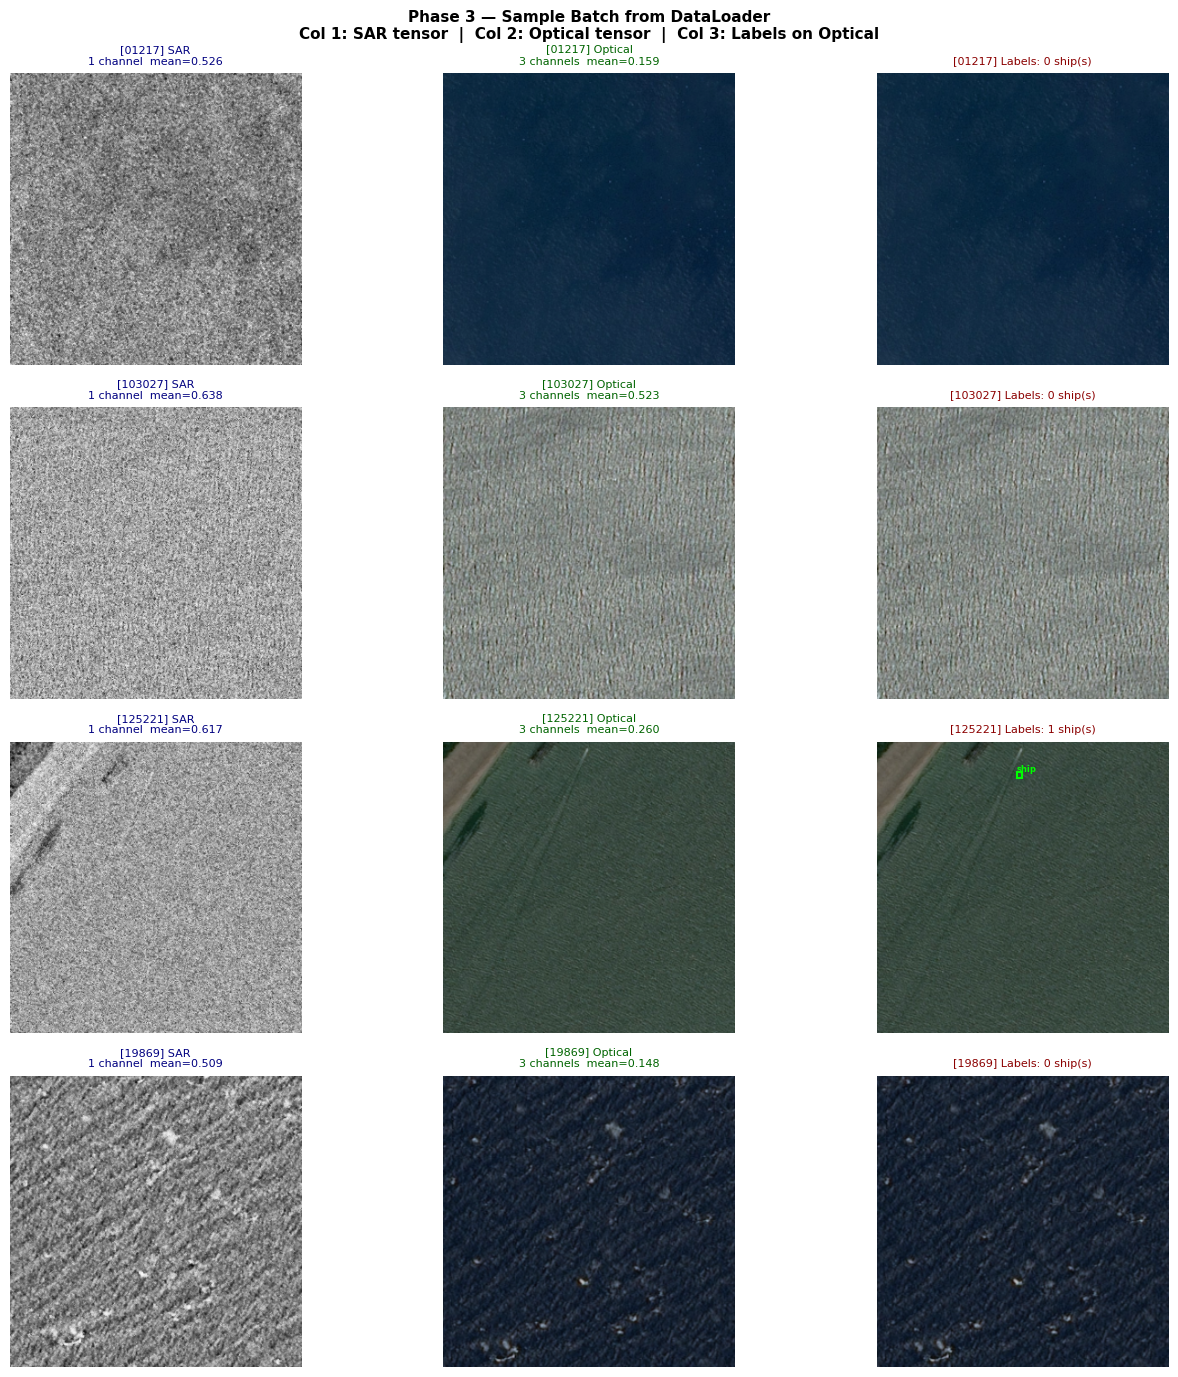

  Saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\dataset_samples\sample_batch_visualisation.png


In [10]:
print('Visualising sample batch for panel demo...')

fig, axes = plt.subplots(BATCH_SIZE, 3, figsize=(14, BATCH_SIZE * 3.5))
fig.suptitle(
    'Phase 3 — Sample Batch from DataLoader\n'
    'Col 1: SAR tensor  |  Col 2: Optical tensor  |  Col 3: Labels on Optical',
    fontsize=11, fontweight='bold'
)

for i in range(BATCH_SIZE):
    seq_id = ids_batch[i]
    ships  = labels_batch[i].shape[0]

    # SAR: [1, H, W] -> [H, W]
    sar_np  = sar_batch[i, 0].numpy()
    # OPT: [3, H, W] -> [H, W, 3]
    opt_np  = opt_batch[i].permute(1, 2, 0).numpy()

    # Column 1: SAR
    axes[i][0].imshow(sar_np, cmap='gray', vmin=0, vmax=1)
    axes[i][0].set_title(f'[{seq_id}] SAR\n1 channel  mean={sar_np.mean():.3f}',
                          fontsize=8, color='navy')
    axes[i][0].axis('off')

    # Column 2: Optical
    axes[i][1].imshow(opt_np)
    axes[i][1].set_title(f'[{seq_id}] Optical\n3 channels  mean={opt_np.mean():.3f}',
                          fontsize=8, color='darkgreen')
    axes[i][1].axis('off')

    # Column 3: Optical with bounding boxes
    axes[i][2].imshow(opt_np)
    axes[i][2].set_title(f'[{seq_id}] Labels: {ships} ship(s)',
                          fontsize=8, color='darkred')
    axes[i][2].axis('off')

    lbl = labels_batch[i]
    for j in range(lbl.shape[0]):
        cls, xc, yc, w, h = lbl[j].tolist()
        px_x = (xc - w/2) * IMG_W
        px_y = (yc - h/2) * IMG_H
        px_w = w * IMG_W
        px_h = h * IMG_H
        rect = patches.Rectangle(
            (px_x, px_y), px_w, px_h,
            linewidth=1.5, edgecolor='lime', facecolor='none'
        )
        axes[i][2].add_patch(rect)
        axes[i][2].text(px_x, px_y - 1, 'ship', fontsize=6, color='lime', fontweight='bold')

plt.tight_layout()
p = os.path.join(OUT_SAMPLES, 'sample_batch_visualisation.png')
plt.savefig(p, dpi=120, bbox_inches='tight')
plt.show()
print(f'  Saved -> {p}')

## Cell 11 — Iterate Multiple Batches and Measure Speed

In [12]:
import time

print('DATALOADER SPEED TEST — Loading 20 batches')
print()

N_BATCHES     = 20
batch_times   = []
ship_counts   = []
bg_counts     = []

start_total   = time.time()

for batch_idx, (sar_b, opt_b, lbl_b, id_b) in enumerate(
        tqdm(train_loader, total=N_BATCHES, desc='Loading batches')):
    t0 = time.time()

    # Count ship vs background in this batch
    ships_in_batch = sum(1 for lbl in lbl_b if lbl.shape[0] > 0)
    bg_in_batch    = BATCH_SIZE - ships_in_batch
    ship_counts.append(ships_in_batch)
    bg_counts.append(bg_in_batch)

    batch_times.append(time.time() - t0)

    if batch_idx == 0:
        print()
        print(f'  First batch details:')
        print(f'    SAR  shape   : {sar_b.shape}')
        print(f'    OPT  shape   : {opt_b.shape}')
        print(f'    Ships/BG     : {ships_in_batch} ship imgs, {bg_in_batch} background imgs')
        print()

    if batch_idx + 1 >= N_BATCHES:
        break

elapsed = time.time() - start_total

print()
print(f'  Speed test results ({N_BATCHES} batches):')
print(f'    Total time          : {elapsed:.2f} seconds')
print(f'    Avg time per batch  : {np.mean(batch_times)*1000:.1f} ms')
print(f'    Batches per second  : {N_BATCHES/elapsed:.1f}')
print(f'    Images per second   : {N_BATCHES*BATCH_SIZE/elapsed:.1f}')
print()
print(f'  Class balance across {N_BATCHES} batches:')
print(f'    Avg ship images per batch  : {np.mean(ship_counts):.1f} / {BATCH_SIZE}')
print(f'    Avg BG images per batch    : {np.mean(bg_counts):.1f} / {BATCH_SIZE}')
print(f'    Ship ratio                 : {np.mean(ship_counts)/BATCH_SIZE*100:.1f}%')
print()
print('DataLoader speed test complete.')

DATALOADER SPEED TEST — Loading 20 batches



Loading batches:   5%|▌         | 1/20 [00:00<00:03,  4.79it/s]


  First batch details:
    SAR  shape   : torch.Size([4, 1, 320, 320])
    OPT  shape   : torch.Size([4, 3, 320, 320])
    Ships/BG     : 1 ship imgs, 3 background imgs



Loading batches:  95%|█████████▌| 19/20 [00:04<00:00,  4.45it/s]


  Speed test results (20 batches):
    Total time          : 4.27 seconds
    Avg time per batch  : 0.1 ms
    Batches per second  : 4.7
    Images per second   : 18.7

  Class balance across 20 batches:
    Avg ship images per batch  : 2.2 / 4
    Avg BG images per batch    : 1.8 / 4
    Ship ratio                 : 56.2%

DataLoader speed test complete.


## Cell 12 — Dataset Statistics Dashboard

Generating dataset statistics dashboard...


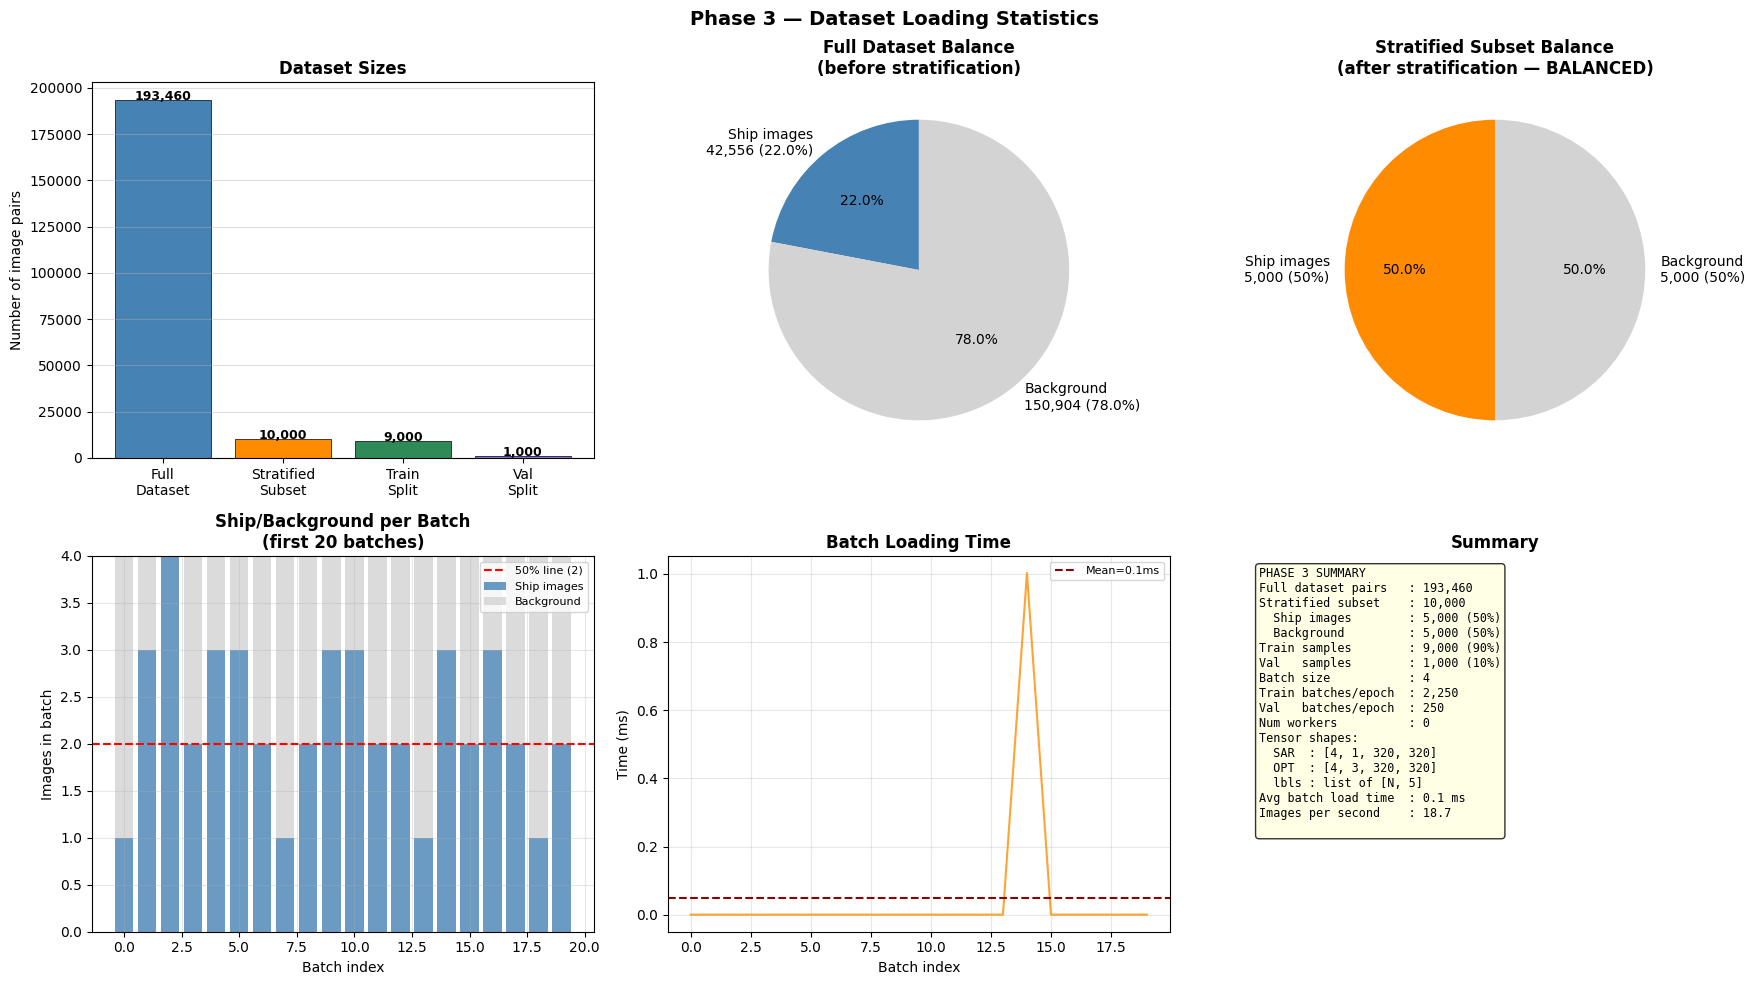

  Saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\dataset_samples\phase3_statistics_dashboard.png


In [13]:
print('Generating dataset statistics dashboard...')

# Count ships in entire stratified subset
subset_ship_count = sum(
    1 for sid in all_sampled_ids
    if os.path.getsize(os.path.join(LABEL_DIR, f'{sid}.txt')) > 0
)
subset_bg_count = len(all_sampled_ids) - subset_ship_count

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 3 — Dataset Loading Statistics', fontsize=14, fontweight='bold')

# Plot 1: Full dataset vs stratified subset vs train/val
ax = axes[0][0]
categories = ['Full\nDataset', 'Stratified\nSubset', 'Train\nSplit', 'Val\nSplit']
values     = [len(ship_ids)+len(bg_ids), TOTAL_SAMPLES, train_size, val_size]
colors     = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+100,
            f'{int(b.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Dataset Sizes', fontweight='bold')
ax.set_ylabel('Number of image pairs')
ax.grid(axis='y', alpha=0.4)

# Plot 2: Ship vs background in full dataset
ax = axes[0][1]
ax.pie([len(ship_ids), len(bg_ids)],
       labels=[f'Ship images\n{len(ship_ids):,} ({len(ship_ids)/(len(ship_ids)+len(bg_ids))*100:.1f}%)',
               f'Background\n{len(bg_ids):,} ({len(bg_ids)/(len(ship_ids)+len(bg_ids))*100:.1f}%)'],
       colors=['steelblue', 'lightgray'],
       autopct='%1.1f%%', startangle=90)
ax.set_title('Full Dataset Balance\n(before stratification)', fontweight='bold')

# Plot 3: Ship vs background in stratified subset
ax = axes[0][2]
ax.pie([subset_ship_count, subset_bg_count],
       labels=[f'Ship images\n{subset_ship_count:,} (50%)',
               f'Background\n{subset_bg_count:,} (50%)'],
       colors=['darkorange', 'lightgray'],
       autopct='%1.1f%%', startangle=90)
ax.set_title('Stratified Subset Balance\n(after stratification — BALANCED)', fontweight='bold')

# Plot 4: Batch composition from speed test
ax = axes[1][0]
x = range(len(ship_counts))
ax.bar(x, ship_counts,  color='steelblue',  label='Ship images', alpha=0.8)
ax.bar(x, bg_counts,    bottom=ship_counts, color='lightgray',   label='Background', alpha=0.8)
ax.axhline(BATCH_SIZE/2, color='red', linestyle='--', label=f'50% line ({BATCH_SIZE//2})')
ax.set_title(f'Ship/Background per Batch\n(first {N_BATCHES} batches)', fontweight='bold')
ax.set_xlabel('Batch index')
ax.set_ylabel('Images in batch')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plot 5: Batch loading time
ax = axes[1][1]
ax.plot(range(len(batch_times)), [t*1000 for t in batch_times],
        color='darkorange', linewidth=1.5, alpha=0.8)
ax.axhline(np.mean(batch_times)*1000, color='darkred', linestyle='--',
           label=f'Mean={np.mean(batch_times)*1000:.1f}ms')
ax.set_title('Batch Loading Time', fontweight='bold')
ax.set_xlabel('Batch index')
ax.set_ylabel('Time (ms)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plot 6: Summary text
ax = axes[1][2]
ax.axis('off')
txt = (
    f'PHASE 3 SUMMARY\n'
    f'Full dataset pairs   : {len(ship_ids)+len(bg_ids):,}\n'
    f'Stratified subset    : {TOTAL_SAMPLES:,}\n'
    f'  Ship images        : {NUM_SHIP_SAMPLES:,} (50%)\n'
    f'  Background         : {NUM_BG_SAMPLES:,} (50%)\n'
    f'Train samples        : {train_size:,} (90%)\n'
    f'Val   samples        : {val_size:,} (10%)\n'
    f'Batch size           : {BATCH_SIZE}\n'
    f'Train batches/epoch  : {len(train_loader):,}\n'
    f'Val   batches/epoch  : {len(val_loader):,}\n'
    f'Num workers          : {NUM_WORKERS}\n'
    f'Tensor shapes:\n'
    f'  SAR  : [4, 1, 320, 320]\n'
    f'  OPT  : [4, 3, 320, 320]\n'
    f'  lbls : list of [N, 5]\n'
    f'Avg batch load time  : {np.mean(batch_times)*1000:.1f} ms\n'
    f'Images per second    : {N_BATCHES*BATCH_SIZE/elapsed:.1f}\n'
)
ax.text(0.03, 0.97, txt, transform=ax.transAxes, fontsize=8.5,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('Summary', fontweight='bold')

plt.tight_layout()
p = os.path.join(OUT_SAMPLES, 'phase3_statistics_dashboard.png')
plt.savefig(p, dpi=120, bbox_inches='tight')
plt.show()
print(f'  Saved -> {p}')

## Cell 13 — Final Summary Report

In [14]:
summary_lines = [
    'PHASE 3 - DATASET LOADING - SUMMARY REPORT',
    f'Run at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    '',
    'PROJECT: Multimodal Maritime Object Detection (SAR + Optical)',
    'Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna',
    '',
    '-- WHAT PHASE 3 DOES --',
    'Builds a PyTorch Dataset and DataLoader to serve batches of',
    '(SAR tensor, optical tensor, label tensor) to the training loop.',
    'Uses stratified sampling to balance ship vs background images.',
    'Splits into 90% train and 10% validation.',
    '',
    '-- WHY STRATIFIED SAMPLING --',
    f'Full dataset: {len(ship_ids):,} ship images (22%), {len(bg_ids):,} background (78%)',
    'Without balancing, model would predict nothing and get 78% accuracy.',
    f'Solution: force 50/50 with {NUM_SHIP_SAMPLES:,} ship + {NUM_BG_SAMPLES:,} background.',
    '',
    '-- DATASET CONFIGURATION --',
    f'Total stratified samples : {TOTAL_SAMPLES:,}',
    f'  Ship samples           : {NUM_SHIP_SAMPLES:,} (50%)',
    f'  Background samples     : {NUM_BG_SAMPLES:,} (50%)',
    f'Train samples            : {train_size:,} (90%)',
    f'Val samples              : {val_size:,} (10%)',
    f'Random seed              : {SEED}',
    '',
    '-- DATALOADER CONFIGURATION --',
    f'Batch size               : {BATCH_SIZE}',
    f'Num workers              : {NUM_WORKERS} (Windows multiprocessing limit)',
    f'Pin memory               : {PIN_MEMORY} (False = CPU only)',
    f'Train batches per epoch  : {len(train_loader):,}',
    f'Val batches per epoch    : {len(val_loader):,}',
    '',
    '-- TENSOR SHAPES PER BATCH --',
    f'SAR tensor     : [4, 1, 320, 320]  float32 [0,1]',
    f'Optical tensor : [4, 3, 320, 320]  float32 [0,1]',
    f'Labels         : list of 4 x [N, 5]  float32',
    f'               : N = number of ships in that image',
    f'               : 5 = [class, x_center, y_center, w, h]',
    '',
    '-- PERFORMANCE --',
    f'Avg batch load time    : {np.mean(batch_times)*1000:.1f} ms',
    f'Images per second      : {N_BATCHES*BATCH_SIZE/elapsed:.1f}',
    f'Device                 : {device}',
    '',
    '-- PANEL DEMO IMAGES SAVED --',
    '  1. sample_batch_visualisation.png  (4 batch images with labels)',
    '  2. phase3_statistics_dashboard.png (full statistics)',
    '',
    '-- NEXT STEP --',
    'Run PHASE4_Backbone.ipynb',
    'train_loader and val_loader are ready to feed the model.',
]

with open(SUMMARY_FILE, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines))

print('\n'.join(summary_lines))
print()
print(f'Summary saved -> {SUMMARY_FILE}')
print()
print('PHASE 3 COMPLETE!')
print(f'  train_loader : {len(train_loader):,} batches x {BATCH_SIZE} images = {train_size:,} training samples')
print(f'  val_loader   : {len(val_loader):,} batches x {BATCH_SIZE} images = {val_size:,} validation samples')
print()
print('train_loader and val_loader are ready for Phase 4: Backbone training.')

PHASE 3 - DATASET LOADING - SUMMARY REPORT
Run at: 2026-04-24 11:18:24

PROJECT: Multimodal Maritime Object Detection (SAR + Optical)
Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna

-- WHAT PHASE 3 DOES --
Builds a PyTorch Dataset and DataLoader to serve batches of
(SAR tensor, optical tensor, label tensor) to the training loop.
Uses stratified sampling to balance ship vs background images.
Splits into 90% train and 10% validation.

-- WHY STRATIFIED SAMPLING --
Full dataset: 42,556 ship images (22%), 150,904 background (78%)
Without balancing, model would predict nothing and get 78% accuracy.
Solution: force 50/50 with 5,000 ship + 5,000 background.

-- DATASET CONFIGURATION --
Total stratified samples : 10,000
  Ship samples           : 5,000 (50%)
  Background samples     : 5,000 (50%)
Train samples            : 9,000 (90%)
Val samples              : 1,000 (10%)
Random seed              : 42

-- DATALOADER CONFIGURATION --
Batch size               : 4
Num workers  